# Evolución de una Acción con Qlib
Este notebook recupera los datos de una acción usando Qlib y muestra una gráfica de la evolución de su valor de cierre desde el 1 de enero de 2020.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import qlib
from qlib.data import D
from qlib.config import REG_US
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configurar el ticker y la fecha de inicio
TICKER = "^GSPC"  # Cambia esto por el ticker que desees analizar (ej: TSLA, MSFT, NVO, GLD)
START_DATE = "2020-01-01"

# Inicializar Qlib con los datos de mercado de US
# Nota: provider_uri debe apuntar a donde tengas descargados los datos de Qlib.
provider_uri = '~/.qlib/qlib_data/us_data'
try:
    qlib.init(provider_uri=provider_uri, region=REG_US)
    print("Qlib inicializado correctamente.")
except Exception as e:
    print(f"Aviso al inicializar Qlib: {e}")

[1539668:MainThread](2026-03-21 17:43:51,717) INFO - qlib.Initialization - [config.py:453] - default_conf: client.
[1539668:MainThread](2026-03-21 17:43:53,103) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[1539668:MainThread](2026-03-21 17:43:53,104) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/home/toni/.qlib/qlib_data/us_data')}


Qlib inicializado correctamente.


Recuperando datos para ^GSPC desde 2020-01-01...


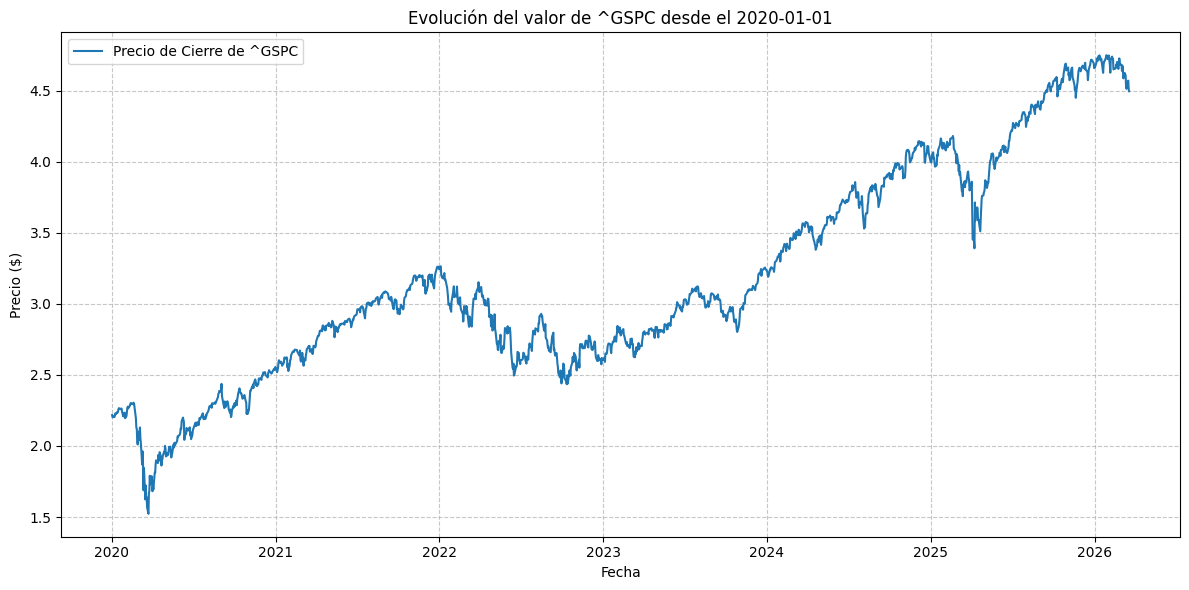

In [3]:
print(f"Recuperando datos para {TICKER} desde {START_DATE}...")

# Recuperar el precio de cierre ($close) de la acción
instruments = [TICKER]
fields = ['$close']
try:
    df = D.features(instruments, fields, start_time=START_DATE)
except Exception as e:
    print(f"Error al recuperar datos: {e}")
    df = None

if df is not None and not df.empty:
    # Qlib devuelve un DataFrame con MultiIndex (instrument, datetime).
    # Seleccionamos solo los datos del ticker especificado
    df_ticker = df.loc[TICKER]
    
    # Crear la gráfica
    plt.figure(figsize=(12, 6))
    plt.plot(df_ticker.index, df_ticker['$close'], label=f'Precio de Cierre de {TICKER}', color='#1f77b4')
    
    plt.title(f'Evolución del valor de {TICKER} desde el {START_DATE}')
    plt.xlabel('Fecha')
    plt.ylabel('Precio ($)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    plt.show()
else:
    print(f"No se encontraron datos para el ticker {TICKER} desde {START_DATE}.")

In [4]:
# Configurar pandas para mostrar todas las columnas sin ocultarlas
pd.set_option('display.max_columns', None)

# Especificar las columnas (features) que queremos traer de Qlib
instruments = [TICKER]
fields = ['$open', '$high', '$low', '$close', '$volume', '$amount', '$factor']

print(f"Recuperando todas las columnas para {TICKER}...")
df_all = D.features(instruments, fields, start_time=START_DATE)

if df_all is not None and not df_all.empty:
    # Qlib devuelve un MultiIndex, seleccionamos el ticker en cuestión
    df_ticker_all = df_all.loc[TICKER]
    
    # Extraer exactamente los últimos 40 registros
    df_40 = df_ticker_all.tail(40)
    
    print(f"Últimos 40 registros de {TICKER} con las columnas extraídas:")
    display(df_40)
else:
    print(f"No se encontraron datos para {TICKER}.")

Recuperando todas las columnas para ^GSPC...
Últimos 40 registros de ^GSPC con las columnas extraídas:


,$open,$high,$low,$close,$volume,$amount,$factor
datetime,,,,,,,
2026-01-22,4.706102,4.719925,4.691931,4.705360,7.798162e+12,NaN,0.000681
2026-01-23,4.701617,4.718707,4.693211,4.706898,7.158083e+12,NaN,0.000681
2026-01-26,4.712084,4.740283,4.710975,4.730461,7.299307e+12,NaN,0.000681
2026-01-27,4.741167,4.756726,4.736314,4.749770,7.833630e+12,NaN,0.000681
2026-01-28,4.765697,4.765887,4.739466,4.749382,8.092144e+12,NaN,0.000681
2026-01-29,4.749185,4.759462,4.676399,4.743243,1.010518e+13,NaN,0.000681
2026-01-30,4.728446,4.739894,4.691836,4.722838,9.840067e+12,NaN,0.000681
2026-02-02,4.707599,4.758836,4.706034,4.748300,8.480584e+12,NaN,0.000681
2026-02-03,4.754433,4.759626,4.670444,4.708395,1.031070e+13,NaN,0.000681


In [5]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['NVO'], ['$close', '$factor'], start_time='2020-03-01', end_time='2026-12-31')
print(df)

                          $close   $factor
instrument datetime                       
NVO        2020-03-02  33.597225  1.099386
           2020-03-03  33.806107  1.099386
           2020-03-04  35.609104  1.099386
           2020-03-05  34.603165  1.099386
           2020-03-06  34.383289  1.099386
...                          ...       ...
           2026-03-13  46.453770  1.223756
           2026-03-16  47.212502  1.223756
           2026-03-17  47.028934  1.223756
           2026-03-18  45.829655  1.223756
           2026-03-19  45.376869  1.223756

[1521 rows x 2 columns]


In [6]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['JPM'], ['$close', '$factor'], start_time='2020-03-01', end_time='2026-12-31')
print(df)

                          $close   $factor
instrument datetime                       
JPM        2020-03-02   4.224773  0.034766
           2020-03-03   4.066240  0.034766
           2020-03-04   4.166713  0.034766
           2020-03-05   3.962289  0.034766
           2020-03-06   3.757517  0.034766
...                          ...       ...
           2026-03-13  11.605235  0.040944
           2026-03-16  11.716604  0.040944
           2026-03-17  11.746493  0.040944
           2026-03-18  11.781295  0.040944
           2026-03-19  11.790712  0.040944

[1521 rows x 2 columns]


In [7]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['^NDX'], ['$close', '$factor'], start_time='2026-03-01', end_time='2026-12-31')
print(df)

                         $close  $factor
instrument datetime                     
^NDX       2026-03-02  6.740492  0.00027
           2026-03-03  6.666994  0.00027
           2026-03-04  6.767754  0.00027
           2026-03-05  6.747993  0.00027
           2026-03-06  6.646211  0.00027
           2026-03-09  6.733655  0.00027
           2026-03-10  6.730748  0.00027
           2026-03-11  6.733051  0.00027
           2026-03-12  6.616695  0.00027
           2026-03-13  6.575471  0.00027
           2026-03-16  6.649533  0.00027
           2026-03-17  6.683268  0.00027
           2026-03-18  6.587435  0.00027
           2026-03-19  6.568607  0.00027
